In [6]:
import pandas as pd
df=pd.read_csv('Advertising.csv')
df=df.drop(columns= {'Unnamed: 0'})
df

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


In [3]:
#mean of the error should be 0
#check if the relationship between x and y be linear
#the variable should be independant (x shoulb be independant)
#x should be correlated with error (no relation between u and x)
# REST ASSUMPTIONS ARE COVERED IN TIME SERIES


In [ ]:
#target=sales
#

In [7]:
#Regression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import scale
import sklearn.linear_model as lm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

Index(['TV', 'radio', 'newspaper', 'sales'], dtype='object')

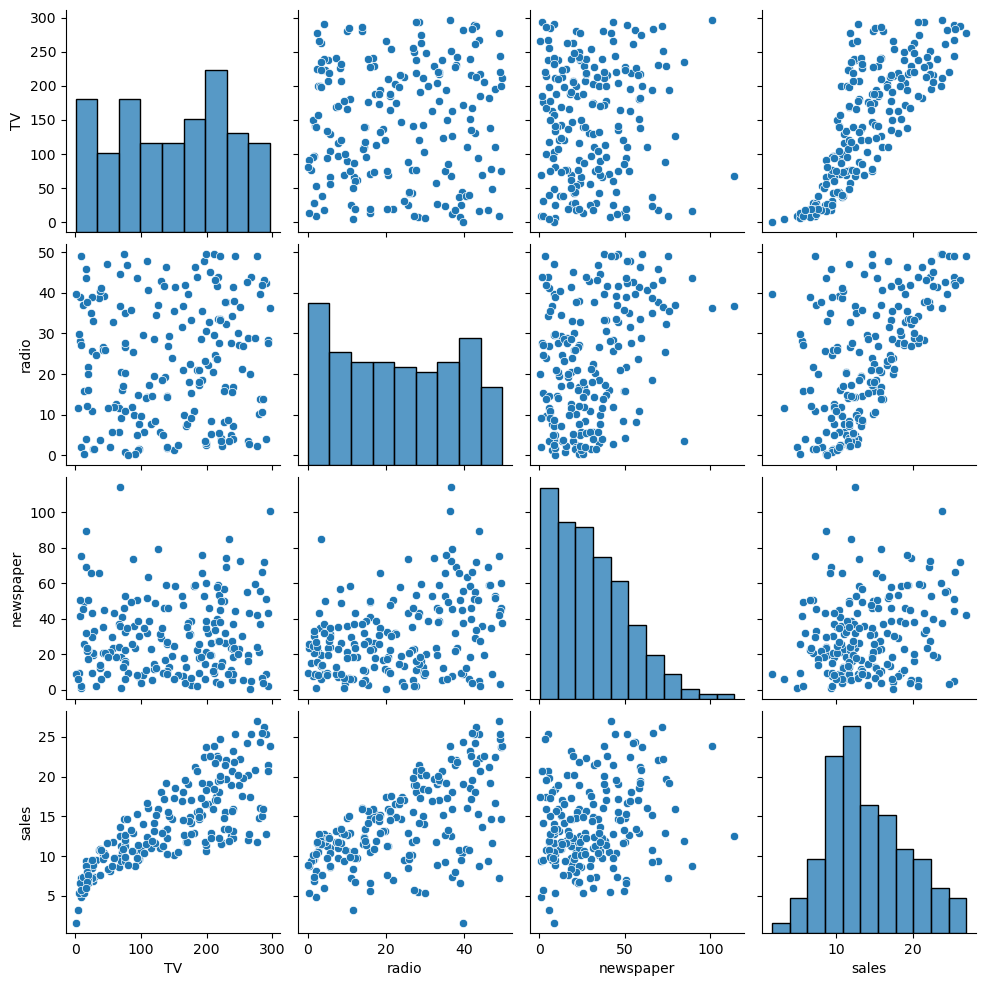

In [10]:
df1=pd.read_csv('Advertising.csv', usecols=[1,2,3,4])
df1.corr()

sns.pairplot(df1[['TV', 'radio', 'newspaper', 'sales']])
df1.columns

<Axes: xlabel='newspaper', ylabel='sales'>

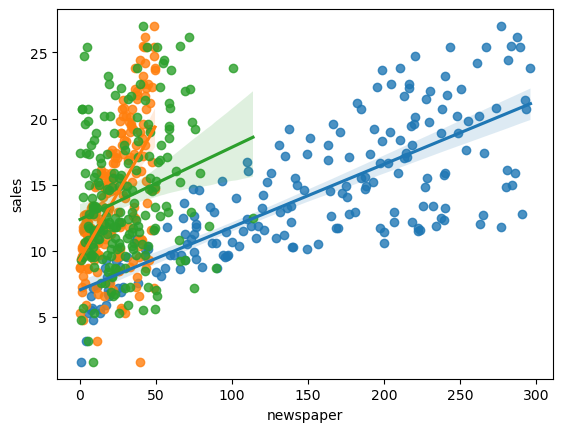

In [15]:
#check linearity by graph
sns.regplot(data=df1, x='TV', y='sales', order=1) #order refers to raise to power in Y=alpha+beta(x)^order
sns.regplot(data=df1, x='radio', y='sales', order=1)
sns.regplot(data=df1, x='newspaper', y='sales', order=1)

In [16]:
#checking linearity using table
lm_fit1=smf.ols('sales~TV', df1).fit()
lm_fit1.summary()  #R square significance is find out by Prob (F-statistic)

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.610
Method:                 Least Squares   F-statistic:                     312.1
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           1.47e-42
Time:                        15:10:30   Log-Likelihood:                -519.05
No. Observations:                 200   AIC:                             1042.
Df Residuals:                     198   BIC:                             1049.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.0326      0.458     15.360      0.000       6.130       7.935
TV             0.0475      0.003     17.668      0.000       0.042       0.053
==============================================================================
Omnibus:                        0.531   Durbin-Watson:                   1.935
Prob(Omnibus):                  0.767   Jarque-Bera (JB):                0.669
Skew:                          -0.089   Prob(JB):                        0.716
Kurtosis:                       2.779   Cond. No.                         338.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [17]:

lm_fit1=smf.ols('sales~radio', df1).fit()
lm_fit1.summary() 

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.332
Model:                            OLS   Adj. R-squared:                  0.329
Method:                 Least Squares   F-statistic:                     98.42
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           4.35e-19
Time:                        15:14:18   Log-Likelihood:                -573.34
No. Observations:                 200   AIC:                             1151.
Df Residuals:                     198   BIC:                             1157.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      9.3116      0.563     16.542      0.000       8.202      10.422
radio          0.2025      0.020      9.921      0.000       0.162       0.243
==============================================================================
Omnibus:                       19.358   Durbin-Watson:                   1.946
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               21.910
Skew:                          -0.764   Prob(JB):                     1.75e-05
Kurtosis:                       3.544   Cond. No.                         51.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [18]:
lm_fit1=smf.ols('sales~newspaper', df1).fit()
lm_fit1.summary()  

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.052
Model:                            OLS   Adj. R-squared:                  0.047
Method:                 Least Squares   F-statistic:                     10.89
Date:                Fri, 20 Mar 2026   Prob (F-statistic):            0.00115
Time:                        15:14:49   Log-Likelihood:                -608.34
No. Observations:                 200   AIC:                             1221.
Df Residuals:                     198   BIC:                             1227.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     12.3514      0.621     19.876      0.000      11.126      13.577
newspaper      0.0547      0.017      3.300      0.001       0.022       0.087
==============================================================================
Omnibus:                        6.231   Durbin-Watson:                   1.983
Prob(Omnibus):                  0.044   Jarque-Bera (JB):                5.483
Skew:                           0.330   Prob(JB):                       0.0645
Kurtosis:                       2.527   Cond. No.                         64.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [19]:
lm_fit1=smf.ols('sales~TV+radio+newspaper', df1).fit()
lm_fit1.summary()  

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           1.58e-96
Time:                        15:19:23   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.9389      0.312      9.422      0.000       2.324       3.554
TV             0.0458      0.001     32.809      0.000       0.043       0.049
radio          0.1885      0.009     21.893      0.000       0.172       0.206
newspaper     -0.0010      0.006     -0.177      0.860      -0.013       0.011
==============================================================================
Omnibus:                       60.414   Durbin-Watson:                   2.084
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              151.241
Skew:                          -1.327   Prob(JB):                     1.44e-33
Kurtosis:                       6.332   Cond. No.                         454.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [20]:
lm_fit1=smf.ols('sales~TV+radio', df1).fit() #dropping newspaper because it had not impact because the p-value>0.05 in the above table
lm_fit1.summary()  

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     859.6
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           4.83e-98
Time:                        15:19:39   Log-Likelihood:                -386.20
No. Observations:                 200   AIC:                             778.4
Df Residuals:                     197   BIC:                             788.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.9211      0.294      9.919      0.000       2.340       3.502
TV             0.0458      0.001     32.909      0.000       0.043       0.048
radio          0.1880      0.008     23.382      0.000       0.172       0.204
==============================================================================
Omnibus:                       60.022   Durbin-Watson:                   2.081
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              148.679
Skew:                          -1.323   Prob(JB):                     5.19e-33
Kurtosis:                       6.292   Cond. No.                         425.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [22]:
#sales=2.92+0.045*TV+0.188*Radio
#other things remaining constant, the impact of radio is more than Tv since 1 Money added would have greater impact of 0.188 in radio than TV
lm_fit1=smf.ols('sales~TV*radio', df1).fit() 
lm_fit1.summary() 

#Y=alpha+beta1*X1+beta2*X2+beta(X1*X2)

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.968
Model:                            OLS   Adj. R-squared:                  0.967
Method:                 Least Squares   F-statistic:                     1963.
Date:                Fri, 20 Mar 2026   Prob (F-statistic):          6.68e-146
Time:                        15:23:53   Log-Likelihood:                -270.14
No. Observations:                 200   AIC:                             548.3
Df Residuals:                     196   BIC:                             561.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.7502      0.248     27.233      0.000       6.261       7.239
TV             0.0191      0.002     12.699      0.000       0.016       0.022
radio          0.0289      0.009      3.241      0.001       0.011       0.046
TV:radio       0.0011   5.24e-05     20.727      0.000       0.001       0.001
==============================================================================
Omnibus:                      128.132   Durbin-Watson:                   2.224
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1183.719
Skew:                          -2.323   Prob(JB):                    9.09e-258
Kurtosis:                      13.975   Cond. No.                     1.80e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.8e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [24]:
#MADE A NEW VARIABLE
df1['TV2']=df1['TV'].values**2
df1.head()

,TV,radio,newspaper,sales,TV2
0,230.1,37.8,69.2,22.1,52946.01
1,44.5,39.3,45.1,10.4,1980.25
2,17.2,45.9,69.3,9.3,295.84
3,151.5,41.3,58.5,18.5,22952.25
4,180.8,10.8,58.4,12.9,32688.64


In [30]:
lm_fit1=smf.ols('sales~TV+TV2', df1).fit() #dropping newspaper because it had not impact because the p-value>0.05 in the above table
lm_fit1.summary()  

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.619
Model:                            OLS   Adj. R-squared:                  0.615
Method:                 Least Squares   F-statistic:                     160.1
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           5.21e-42
Time:                        15:31:38   Log-Likelihood:                -517.18
No. Observations:                 200   AIC:                             1040.
Df Residuals:                     197   BIC:                             1050.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.1141      0.659      9.275      0.000       4.814       7.414
TV             0.0673      0.011      6.349      0.000       0.046       0.088
TV2        -6.847e-05   3.56e-05     -1.924      0.056      -0.000    1.69e-06
==============================================================================
Omnibus:                        0.681   Durbin-Watson:                   1.967
Prob(Omnibus):                  0.712   Jarque-Bera (JB):                0.770
Skew:                          -0.012   Prob(JB):                        0.681
Kurtosis:                       2.697   Cond. No.                     1.11e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.11e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [29]:
df1['radio2']=df1['radio'].values**2
df1.head()

,TV,radio,newspaper,sales,TV2,radio2
0,230.1,37.8,69.2,22.1,52946.01,1428.84
1,44.5,39.3,45.1,10.4,1980.25,1544.49
2,17.2,45.9,69.3,9.3,295.84,2106.81
3,151.5,41.3,58.5,18.5,22952.25,1705.69
4,180.8,10.8,58.4,12.9,32688.64,116.64


In [31]:
lm_fit1=smf.ols('sales~radio+radio2', df1).fit() 
lm_fit1.summary()  

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.332
Model:                            OLS   Adj. R-squared:                  0.326
Method:                 Least Squares   F-statistic:                     49.03
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           5.23e-18
Time:                        15:31:52   Log-Likelihood:                -573.29
No. Observations:                 200   AIC:                             1153.
Df Residuals:                     197   BIC:                             1162.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      9.4861      0.803     11.811      0.000       7.902      11.070
radio          0.1789      0.080      2.236      0.026       0.021       0.337
radio2         0.0005      0.002      0.305      0.761      -0.003       0.004
==============================================================================
Omnibus:                       19.609   Durbin-Watson:                   1.940
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               22.260
Skew:                          -0.769   Prob(JB):                     1.47e-05
Kurtosis:                       3.551   Cond. No.                     2.81e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.81e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [32]:
df1['newspaper2']=df1['newspaper'].values**2
df1.head()

,TV,radio,newspaper,sales,TV2,radio2,newspaper2
0,230.1,37.8,69.2,22.1,52946.01,1428.84,4788.64
1,44.5,39.3,45.1,10.4,1980.25,1544.49,2034.01
2,17.2,45.9,69.3,9.3,295.84,2106.81,4802.49
3,151.5,41.3,58.5,18.5,22952.25,1705.69,3422.25
4,180.8,10.8,58.4,12.9,32688.64,116.64,3410.56


In [33]:
lm_fit1=smf.ols('sales~newspaper+newspaper2', df1).fit()  #newspaper2 is non linear
lm_fit1.summary()  

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.052
Model:                            OLS   Adj. R-squared:                  0.043
Method:                 Least Squares   F-statistic:                     5.417
Date:                Fri, 20 Mar 2026   Prob (F-statistic):            0.00513
Time:                        15:32:41   Log-Likelihood:                -608.33
No. Observations:                 200   AIC:                             1223.
Df Residuals:                     197   BIC:                             1233.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     12.3769      0.863     14.347      0.000      10.676      14.078
newspaper      0.0527      0.049      1.086      0.279      -0.043       0.149
newspaper2  2.424e-05      0.001      0.043      0.966      -0.001       0.001
==============================================================================
Omnibus:                        6.203   Durbin-Watson:                   1.984
Prob(Omnibus):                  0.045   Jarque-Bera (JB):                5.459
Skew:                           0.329   Prob(JB):                       0.0653
Kurtosis:                       2.528   Cond. No.                     5.58e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.58e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [49]:
lm_fit1 = smf.ols('sales~TV*radio', df1).fit() 
lm_fit1.summary()
x=df[['TV', 'radio']]
ypredict=lm_fit1.predict(x)
ypredict #whatever the model predicted the values for sales using TV*radio

0      21.686390
1      10.634546
2       9.261214
3      17.634108
4      12.636919
         ...    
195     7.740230
196     9.192461
197    12.187990
198    26.320875
199    13.600487
Length: 200, dtype: float64

In [48]:
a=(df['sales']-ypredict).sum()
print(a)

-4.087397087459976e-12


In [57]:
lm_fit1 = smf.ols('sales~TV*radio', df1).fit() 
lm_fit1.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.968
Model:                            OLS   Adj. R-squared:                  0.967
Method:                 Least Squares   F-statistic:                     1963.
Date:                Fri, 20 Mar 2026   Prob (F-statistic):          6.68e-146
Time:                        15:53:09   Log-Likelihood:                -270.14
No. Observations:                 200   AIC:                             548.3
Df Residuals:                     196   BIC:                             561.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.7502      0.248     27.233      0.000       6.261       7.239
TV             0.0191      0.002     12.699      0.000       0.016       0.022
radio          0.0289      0.009      3.241      0.001       0.011       0.046
TV:radio       0.0011   5.24e-05     20.727      0.000       0.001       0.001
==============================================================================
Omnibus:                      128.132   Durbin-Watson:                   2.224
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1183.719
Skew:                          -2.323   Prob(JB):                    9.09e-258
Kurtosis:                      13.975   Cond. No.                     1.80e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.8e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [58]:
#TV=1000, radio=2000 would like to spend
print(6.7502+0.0191*1000+0.0289*2000+0.0011*(1000*2000))

2283.6502


In [ ]:
# ============================================================
# COMPLETE LINEAR REGRESSION PIPELINE - Advertising Dataset
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm

# ============================================================
# STEP 1: LOAD & EXPLORE DATA
# ============================================================
df = pd.read_csv('Advertising.csv', usecols=[1, 2, 3, 4])

print("="*50)
print("STEP 1: DATA EXPLORATION")
print("="*50)
print("\nShape:", df.shape)
print("\nFirst 5 rows:\n", df.head())
print("\nStatistics:\n", df.describe())
print("\nData types & nulls:"); df.info()

# ============================================================
# STEP 2: CHECK ASSUMPTIONS - VISUALISE LINEARITY
# ============================================================
print("\n" + "="*50)
print("STEP 2: CHECKING ASSUMPTIONS")
print("="*50)

# Pairplot - see all relationships at once
sns.pairplot(df[['TV', 'radio', 'newspaper', 'sales']])
plt.suptitle("Pairplot - Check for Linear Relationships", y=1.02)
plt.show()

# Regplots - check linearity for each predictor
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['TV', 'radio', 'newspaper']):
    sns.regplot(data=df, x=col, y='sales', order=1, ax=ax)
    ax.set_title(f'{col} vs sales')
plt.suptitle("Step 2: Linearity Check (order=1 = straight line fit)")
plt.tight_layout()
plt.show()

# ============================================================
# STEP 3: CORRELATION CHECK
# ============================================================
print("\n" + "="*50)
print("STEP 3: CORRELATION MATRIX")
print("="*50)
print("\nCorrelation table:\n", df.corr())

plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Step 3: Correlation Heatmap")
plt.tight_layout()
plt.show()

# ============================================================
# STEP 4: SIMPLE LINEAR REGRESSION (one predictor at a time)
# ============================================================
print("\n" + "="*50)
print("STEP 4: SIMPLE LINEAR REGRESSION")
print("="*50)

for predictor in ['TV', 'radio', 'newspaper']:
    lm = smf.ols(f'sales ~ {predictor}', df).fit()
    print(f"\n--- sales ~ {predictor} ---")
    print(f"  R-squared      : {lm.rsquared:.4f}  (higher = better fit)")
    print(f"  F-statistic p  : {lm.f_pvalue:.4e}  (< 0.05 = model is significant)")
    print(f"  Coefficient    : {lm.params[predictor]:.4f}  (effect per unit)")
    print(f"  p-value        : {lm.pvalues[predictor]:.4e}  (< 0.05 = variable matters)")

# ============================================================
# STEP 5: MULTIPLE LINEAR REGRESSION
# ============================================================
print("\n" + "="*50)
print("STEP 5: MULTIPLE LINEAR REGRESSION")
print("="*50)

# All three predictors
lm_full = smf.ols('sales ~ TV + radio + newspaper', df).fit()
print("\n--- Full model: TV + radio + newspaper ---")
print(lm_full.summary())

# Drop newspaper (p-value > 0.05 = not significant)
lm_final = smf.ols('sales ~ TV + radio', df).fit()
print("\n--- Reduced model: TV + radio (newspaper dropped) ---")
print(lm_final.summary())
print("\nEquation: sales = {:.4f} + {:.4f}*TV + {:.4f}*radio".format(
    lm_final.params['Intercept'], lm_final.params['TV'], lm_final.params['radio']))

# ============================================================
# STEP 6: INTERACTION TERMS (synergy between variables)
# ============================================================
print("\n" + "="*50)
print("STEP 6: INTERACTION TERMS")
print("="*50)

lm_interact = smf.ols('sales ~ TV * radio', df).fit()
# Expands to: sales = intercept + b1*TV + b2*radio + b3*(TV x radio)
print(lm_interact.summary())
print("\nEquation: sales = {:.4f} + {:.4f}*TV + {:.4f}*radio + {:.4f}*(TV x radio)".format(
    lm_interact.params['Intercept'],
    lm_interact.params['TV'],
    lm_interact.params['radio'],
    lm_interact.params['TV:radio']))

# ============================================================
# STEP 7: POLYNOMIAL TERMS (handling non-linearity)
# ============================================================
print("\n" + "="*50)
print("STEP 7: POLYNOMIAL / NON-LINEAR TERMS")
print("="*50)

for col in ['TV', 'radio', 'newspaper']:
    df[f'{col}2'] = df[col] ** 2
    lm_poly = smf.ols(f'sales ~ {col} + {col}2', df).fit()
    sig = "SIGNIFICANT - non-linear!" if lm_poly.pvalues[f'{col}2'] < 0.05 else "Not significant - linear is fine"
    print(f"\n{col}² p-value: {lm_poly.pvalues[f'{col}2']:.4e}  → {sig}")

# ============================================================
# STEP 8: PREDICT & VALIDATE
# ============================================================
print("\n" + "="*50)
print("STEP 8: PREDICTION & VALIDATION")
print("="*50)

# Use the interaction model (best performing)
lm_best = smf.ols('sales ~ TV * radio', df).fit()
y_predict = lm_best.predict(df[['TV', 'radio']])

residuals = df['sales'] - y_predict
print(f"\nSum of residuals: {residuals.sum():.6f}  (should be ~0)")
print(f"Mean of residuals: {residuals.mean():.6f} (should be ~0)")

# Residual plot
plt.figure(figsize=(8, 4))
plt.scatter(y_predict, residuals, alpha=0.5, color='steelblue')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Step 8: Residual Plot (points should scatter randomly around 0)")
plt.tight_layout()
plt.show()

# Forecast for new data point
TV_spend    = 1000
radio_spend = 2000
b = lm_best.params
forecast = (b['Intercept'] + b['TV']*TV_spend +
            b['radio']*radio_spend + b['TV:radio']*TV_spend*radio_spend)
print(f"\nForecast: TV={TV_spend}, radio={radio_spend} → Predicted sales = {forecast:.2f}")

# ============================================================
# STEP 9: FINAL CONCLUSION
# ============================================================
print("\n" + "="*50)
print("STEP 9: CONCLUSION")
print("="*50)
b = lm_best.params
print(f"""
Best model:  sales ~ TV * radio  (interaction model)

Equation:
  sales = {b['Intercept']:.4f}
        + {b['TV']:.4f} * TV
        + {b['radio']:.4f} * radio
        + {b['TV:radio']:.4f} * (TV × radio)

R-squared : {lm_best.rsquared:.4f}
F-stat p   : {lm_best.f_pvalue:.2e}

Key findings:
  - TV and radio are both significant predictors of sales
  - Newspaper is NOT significant (p > 0.05) — excluded from final model
  - The interaction term (TV × radio) IS significant → synergy effect exists
  - Combined TV + radio spending yields MORE sales than each alone
  - Radio has a larger per-unit impact than TV
""")